# MATLAB Custom Stats QC

**Purpose:** Validate that the 12 custom seasonal hydrological statistics computed by MATLAB
(`custom_stats.m`) match a clean Python reimplementation run on the same input data.

The MATLAB workflow processes 34,346 stream segments × 7 climate models × 2 eras = ~480K time
series. This notebook spot-checks **50 randomly selected streams across all 14 model/era
combinations** (700 total comparisons) and reports the agreement between MATLAB and Python.

**Who this is for:** Python-familiar reviewers who want to audit the calculations without
reading MATLAB. Section 2 contains the full Python reimplementation of `custom_stats.m` with
extensive comments explaining each statistic.

**Inputs:**
- `combined_q.nc` — raw daily discharge (m³/s) for all streams, models, and times
- `drainage_area_lookup.csv` — drainage area per stream in square miles
- `mhit_indices_combined.nc` — MATLAB-computed statistics (source=`original_gcm`)

**The 12 custom stats being validated:**

| Stat | Description |
|------|-------------|
| `lf1` | Median days/yr with flow below 0.1 × drainage area threshold |
| `spr_dur3` | Median of annual max 3-day rolling mean, Apr–Jun |
| `spr_dur7` | Median of annual max 7-day rolling mean, Apr–Jun |
| `sum_dur3` | Median of annual min 3-day rolling mean, Jul–Sep |
| `sum_dur7` | Median of annual min 7-day rolling mean, Jul–Sep |
| `spr_freq` | Median count/yr of Apr–Jun flow events above 10th percentile |
| `sum_freq` | Median count/yr of Jul–Sep flow events below 90th percentile |
| `spr_mag` | Median spring peak / drainage area (cfs/mi²) |
| `sum_cv` | Median summer (Jul–Sep) coefficient of variation (%) |
| `sum_mag` | Median summer minimum / drainage area (cfs/mi²) |
| `spr_ord` | Median Julian day of spring (Apr–Jun) daily peak |
| `sum_ord` | Median Julian day of summer (Jul–Sep) daily minimum |

**Run this notebook using the `snap-geo` conda environment**

## 1. Setup

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)  # reproducible stream sampling

# ── Paths ────────────────────────────────────────────────────────────────────
Q_NC    = Path("/beegfs/CMIP6/jdpaul3/arctic_rivers_data/combined_q.nc")
MHIT_NC = Path("/beegfs/CMIP6/jdpaul3/arctic_rivers_data/mhit_indices_combined.nc") # dont use the Rasdaman-ready version, we want to query by model and era strings (not integers)
DA_CSV  = Path("/beegfs/CMIP6/jdpaul3/arctic_rivers_data/drainage_area_lookup.csv")

# ── Constants that must match mhit_chunk.py exactly ─────────────────────────
ERA_CUTOFF = np.datetime64("2022-01-01")
ERA_LABELS = ["1990-2021", "2034-2065"]
MODELS     = ["C2LE2", "C2LE4", "C2LE7", "C2LE9", "PGWh", "PGWm", "historical"]

CUSTOM_STATS = [
    "lf1", "spr_dur3", "spr_dur7", "sum_dur3", "sum_dur7",
    "spr_freq", "sum_freq", "spr_mag", "sum_cv", "sum_mag",
    "spr_ord", "sum_ord",
]

STAT_LABELS = {
    "lf1":      "LF1: low-flow days/yr",
    "spr_dur3": "SPR_DUR3: spring max 3-day mean",
    "spr_dur7": "SPR_DUR7: spring max 7-day mean",
    "sum_dur3": "SUM_DUR3: summer min 3-day mean",
    "sum_dur7": "SUM_DUR7: summer min 7-day mean",
    "spr_freq": "SPR_FREQ: spring event count/yr",
    "sum_freq": "SUM_FREQ: summer event count/yr",
    "spr_mag":  "SPR_MAG: spring peak / DA",
    "sum_cv":   "SUM_CV: summer CV (%)",
    "sum_mag":  "SUM_MAG: summer min / DA",
    "spr_ord":  "SPR_ORD: spring peak Julian day",
    "sum_ord":  "SUM_ORD: summer min Julian day",
}

## 2. Python reimplementation of `custom_stats.m`

This function is a direct Python translation of `processing/matlab/custom_stats.m`.
The logic should be identical; only the syntax differs.

**Key MATLAB→Python translations used throughout:**
- `movmean(x, k)` → `pd.Series(x).rolling(k, center=True, min_periods=1).mean().values`
  (centered rolling mean; edges use fewer points than the full window)
- `nanmedian(x)` → `np.nanmedian(x)` (median ignoring NaN)
- `prctile(x, p)` → `np.percentile(x, p)` (linear interpolation; identical to MATLAB)
- `std(x)` → `np.std(x, ddof=1)` (sample std; MATLAB uses ddof=1 by default)
- `[val, idx] = max(x)` → `idx = np.nanargmax(x)` (MATLAB's max ignores NaN)
- `diff([0; v; 0])` → `np.diff(np.concatenate([[0], v, [0]]))` (edge-detection trick)
- Array indexing: MATLAB uses `()` and is 1-indexed; Python uses `[]` and is 0-indexed

In [ ]:
def custom_stats(discharge, yr, mo, dy, da_mi2):
    """
    Python port of processing/matlab/custom_stats.m.

    Parameters
    ----------
    discharge : array-like, shape (N,)
        Daily streamflow values in whatever units combined_q.nc uses (m³/s from IRFroutedRunoff).
        Unit consistency is what matters — the threshold in lf1 uses the same units as the flow.
    yr, mo, dy : array-like, shape (N,)
        Year, month (1-12), day-of-month for each observation.
    da_mi2 : float
        Drainage area in square miles. Pass np.nan if unavailable.

    Returns
    -------
    dict mapping stat name → float (NaN if uncomputable)
    """
    stats = {k: np.nan for k in CUSTOM_STATS}

    discharge = np.asarray(discharge, dtype=float)
    yr = np.asarray(yr, dtype=float)
    mo = np.asarray(mo, dtype=float)
    dy = np.asarray(dy, dtype=float)

    years = np.unique(yr)
    nyrs  = len(years)

    # ── LF1: median days/yr with flow below 0.1 × da_mi2 ────────────────────
    # Requires drainage area to convert the per-unit-area threshold (0.1) into
    # an absolute flow threshold for this specific gage.
    if not np.isnan(da_mi2) and da_mi2 > 0:
        threshold = 0.1 * da_mi2
        days_below = np.zeros(nyrs)
        for i, y in enumerate(years):
            mask = yr == y
            # nansum treats NaN days as neither above nor below threshold.
            days_below[i] = np.nansum(discharge[mask] < threshold)
        stats["lf1"] = np.nanmedian(days_below)

    # ── SPR_DUR3/7, SUM_DUR3/7: rolling-mean magnitude stats ────────────────
    # Spring (Apr-Jun): median of annual max of a centered k-day rolling mean.
    # Summer (Jul-Sep): median of annual min of a centered k-day rolling mean.
    # Rolling means suppress noise so the stat reflects sustained flow, not
    # a single anomalous day.
    spr_max3 = np.full(nyrs, np.nan)
    spr_max7 = np.full(nyrs, np.nan)
    sum_min3 = np.full(nyrs, np.nan)
    sum_min7 = np.full(nyrs, np.nan)

    for i, y in enumerate(years):
        # Spring Apr-Jun
        spr_mask = (yr == y) & (mo >= 4) & (mo <= 6)
        q_spr = discharge[spr_mask]
        q_spr = q_spr[~np.isnan(q_spr)]  # drop NaN before rolling (MATLAB: q_spr(~isnan(q_spr)))
        if len(q_spr) >= 3:
            rm3 = pd.Series(q_spr).rolling(3, center=True, min_periods=1).mean().values
            spr_max3[i] = np.max(rm3)
        if len(q_spr) >= 7:
            rm7 = pd.Series(q_spr).rolling(7, center=True, min_periods=1).mean().values
            spr_max7[i] = np.max(rm7)

        # Summer Jul-Sep
        sum_mask = (yr == y) & (mo >= 7) & (mo <= 9)
        q_sum = discharge[sum_mask]
        q_sum = q_sum[~np.isnan(q_sum)]
        if len(q_sum) >= 3:
            rm3 = pd.Series(q_sum).rolling(3, center=True, min_periods=1).mean().values
            sum_min3[i] = np.min(rm3)
        if len(q_sum) >= 7:
            rm7 = pd.Series(q_sum).rolling(7, center=True, min_periods=1).mean().values
            sum_min7[i] = np.min(rm7)

    stats["spr_dur3"] = np.nanmedian(spr_max3)
    stats["spr_dur7"] = np.nanmedian(spr_max7)
    stats["sum_dur3"] = np.nanmedian(sum_min3)
    stats["sum_dur7"] = np.nanmedian(sum_min7)

    # ── Percentile thresholds for frequency stats (computed from full record) ─
    q_clean = discharge[~np.isnan(discharge)]
    if len(q_clean) < 2:
        return stats  # can't compute percentiles — exit early, rest stay NaN

    p10 = np.percentile(q_clean, 10)  # record-wide 10th percentile
    p90 = np.percentile(q_clean, 90)  # record-wide 90th percentile

    # ── SPR_FREQ: count distinct spring high-flow events per year ────────────
    # An "event" is a contiguous run of days where flow > p10.
    # The edge-detection trick: prepend/append 0 to the boolean array, then
    # diff() produces +1 at the start of each event (0→1 transition).
    # Counting +1s counts events without needing explicit loop bookkeeping.
    spr_ev = np.full(nyrs, np.nan)
    for i, y in enumerate(years):
        mask = (yr == y) & (mo >= 4) & (mo <= 6)
        q = discharge[mask]
        if len(q) == 0:
            continue
        above = (q > p10).astype(int)
        above[np.isnan(q)] = 0  # NaN days treated as "not in event"
        trans = np.diff(np.concatenate([[0], above, [0]]))
        spr_ev[i] = np.sum(trans == 1)  # count 0→1 transitions = number of events
    stats["spr_freq"] = np.nanmedian(spr_ev)

    # ── SUM_FREQ: count distinct summer low-flow spells per year ─────────────
    # Same edge-detection logic but for flow < p90 in Jul-Sep.
    sum_ev = np.full(nyrs, np.nan)
    for i, y in enumerate(years):
        mask = (yr == y) & (mo >= 7) & (mo <= 9)
        q = discharge[mask]
        if len(q) == 0:
            continue
        below = (q < p90).astype(int)
        below[np.isnan(q)] = 0
        trans = np.diff(np.concatenate([[0], below, [0]]))
        sum_ev[i] = np.sum(trans == 1)
    stats["sum_freq"] = np.nanmedian(sum_ev)

    # ── SPR_MAG, SUM_MAG: drainage-area-normalized peak / trough ─────────────
    # Dividing by drainage area makes gages with very different basin sizes
    # comparable. Units: whatever flow units / mi².
    if not np.isnan(da_mi2) and da_mi2 > 0:
        spr_max_vals = np.full(nyrs, np.nan)
        sum_min_vals = np.full(nyrs, np.nan)
        for i, y in enumerate(years):
            spr_mask = (yr == y) & (mo >= 4) & (mo <= 6)
            q_spr = discharge[spr_mask]
            if len(q_spr) > 0:
                spr_max_vals[i] = np.nanmax(q_spr)
            sum_mask = (yr == y) & (mo >= 7) & (mo <= 9)
            q_sum = discharge[sum_mask]
            if len(q_sum) > 0:
                sum_min_vals[i] = np.nanmin(q_sum)
        stats["spr_mag"] = np.nanmedian(spr_max_vals / da_mi2)
        stats["sum_mag"] = np.nanmedian(sum_min_vals / da_mi2)

    # ── SUM_CV: summer coefficient of variation ───────────────────────────────
    # CV = std / mean × 100. Computed per year over Jul-Sep, then median.
    # ddof=1 (sample std) matches MATLAB's default std() behavior.
    sum_cv_vals = np.full(nyrs, np.nan)
    for i, y in enumerate(years):
        mask = (yr == y) & (mo >= 7) & (mo <= 9)
        q = discharge[mask]
        q = q[~np.isnan(q)]
        if len(q) > 1 and np.mean(q) != 0:
            sum_cv_vals[i] = np.std(q, ddof=1) / np.mean(q) * 100
    stats["sum_cv"] = np.nanmedian(sum_cv_vals)

    # ── Timing: Julian day helpers ────────────────────────────────────────────
    # Julian day = day-of-year (1-365, non-leap-year basis).
    # cum_days[m-1] gives the number of days before month m starts.
    # Example: April (month 4) → cum_days[3] = 90, so Apr 15 → Julian day 105.
    days_per_month = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
    cum_days = np.concatenate([[0], np.cumsum(days_per_month[:11])])
    # cum_days = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]

    # ── SPR_ORD: Julian day of spring (Apr-Jun) peak, median over calendar yrs ─
    # Uses calendar years (Jan-Dec).
    spr_jday = np.full(nyrs, np.nan)
    for i, y in enumerate(years):
        mask = (yr == y) & (mo >= 4) & (mo <= 6)
        if not np.any(mask):
            continue
        q = discharge[mask]
        if np.all(np.isnan(q)):
            continue
        # nanargmax matches MATLAB's max() which ignores NaN.
        idx = np.nanargmax(q)
        spr_jday[i] = cum_days[int(mo[mask][idx]) - 1] + dy[mask][idx]
    stats["spr_ord"] = np.nanmedian(spr_jday)

    # ── SUM_ORD: Julian day of summer (Jul-Sep) min, median over water years ──
    # Uses WATER YEARS (Oct-Sep) so the Jul-Sep window stays paired with the
    # preceding winter/spring within the same hydrological year.
    # Water year assignment: months Jan-Sep belong to the previous water year
    # (water_yr = calendar_yr - 1); months Oct-Dec start a new one.
    water_yr = yr - (mo <= 9).astype(float)  # matches: water_yr = yr - (mo <= 9) in MATLAB
    wyrs = np.unique(water_yr)
    sum_jday = np.full(len(wyrs), np.nan)
    for i, wy in enumerate(wyrs):
        mask = (water_yr == wy) & (mo >= 7) & (mo <= 9)
        if not np.any(mask):
            continue
        q = discharge[mask]
        if np.all(np.isnan(q)):
            continue
        idx = np.nanargmin(q)
        sum_jday[i] = cum_days[int(mo[mask][idx]) - 1] + dy[mask][idx]
    stats["sum_ord"] = np.nanmedian(sum_jday)

    return stats

## 3. Preprocessing helper

MATLAB (`mhit_runner.m`) applies two preprocessing steps before calling `custom_stats`:

1. **Clip to complete water years.** A water year runs Oct 1 – Sep 30. Any water year
   that doesn't have all 12 calendar months represented is dropped. This removes the
   partial years at the start and end of each era.

2. **Drop NaN rows.** A small number of days (~10–18 per series) have NaN discharge.
   These are removed entirely before computing stats.

3. **Minimum length check.** Series with fewer than 730 valid days are skipped (return `None`).

The Python QC must apply the exact same steps so the inputs to `custom_stats` are identical
to what MATLAB received.

In [4]:
def preprocess(q_raw, times):
    """
    Apply the same preprocessing as mhit_runner.m before calling custom_stats.

    Parameters
    ----------
    q_raw : array-like, shape (N,)
        Raw daily discharge values (float32 from NC, promoted to float64 here).
    times : array-like of datetime64
        Timestamps corresponding to q_raw.

    Returns
    -------
    (q, yr, mo, dy) arrays ready to pass to custom_stats, or None if the
    series is too short after filtering.
    """
    times_pd = pd.DatetimeIndex(times)
    yr = times_pd.year.values.astype(float)
    mo = times_pd.month.values.astype(float)
    dy = times_pd.day.values.astype(float)
    q  = np.asarray(q_raw, dtype=float)

    # Step 1: keep only complete water years (all 12 months present).
    # A water year is identified by: water_yr = calendar_yr - (month <= 9)
    water_yr = yr - (mo <= 9).astype(float)
    wy_unique = np.unique(water_yr)
    complete_wys = [
        wy for wy in wy_unique
        if len(np.unique(mo[water_yr == wy])) >= 12
    ]
    keep = np.isin(water_yr, complete_wys)
    q, yr, mo, dy = q[keep], yr[keep], mo[keep], dy[keep]

    # Step 2: drop NaN discharge rows.
    valid = ~np.isnan(q)
    q, yr, mo, dy = q[valid], yr[valid], mo[valid], dy[valid]

    # Step 3: minimum length check.
    if len(q) < 730:
        return None

    return q, yr, mo, dy

## 4. Load data

In [5]:
print("Loading discharge NC...")
q_ds = xr.open_dataset(Q_NC)
all_stream_ids = q_ds["stream_id"].values
time_vals      = q_ds["time"].values       # datetime64 array, length 23216
era0_mask      = time_vals < ERA_CUTOFF    # 1990-2021
era1_mask      = ~era0_mask                # 2034-2065
era_masks      = [era0_mask, era1_mask]

print("Loading MHIT results NC...")
mhit_ds = xr.open_dataset(MHIT_NC)

print("Loading drainage area CSV...")
da_df = pd.read_csv(DA_CSV)
da_df["comid"] = da_df["comid"].astype(np.int64)
da_lookup = dict(zip(da_df["comid"], da_df["uparea_mi2"]))

print(f"\nDataset summary:")
print(f"  Streams: {len(all_stream_ids):,}")
print(f"  Models:  {list(q_ds['model'].values)}")
print(f"  Era 0 ({ERA_LABELS[0]}): {era0_mask.sum():,} days")
print(f"  Era 1 ({ERA_LABELS[1]}): {era1_mask.sum():,} days")
print(f"  Streams with drainage area: {len(da_df):,}")
print(f"  MHIT NC sources: {list(mhit_ds['source'].values)}")

Loading discharge NC...
Loading MHIT results NC...
Loading drainage area CSV...

Dataset summary:
  Streams: 34,346
  Models:  ['C2LE2', 'C2LE4', 'C2LE7', 'C2LE9', 'PGWh', 'PGWm', 'historical']
  Era 0 (1990-2021): 11,609 days
  Era 1 (2034-2065): 11,607 days
  Streams with drainage area: 34,346
  MHIT NC sources: ['original_gcm', 'gcm_diff', 'gcm_diff_applied_to_cheng']


## 5. Stratified stream sampling

50 streams are sampled across four drainage-area tiers so both code paths in `custom_stats`
are exercised:
- **No DA** (drainage area = NaN): stats that require `da_mi2` (`lf1`, `spr_mag`, `sum_mag`)
  will be NaN from both Python and MATLAB — testing NaN agreement.
- **Small** (< 100 mi²), **Medium** (100–1000 mi²), **Large** (> 1000 mi²): all 12 stats
  should be computable.

In [6]:
# Build a DataFrame of all streams with their drainage area tier.
stream_df = pd.DataFrame({"stream_id": all_stream_ids})
stream_df["da_mi2"] = stream_df["stream_id"].map(da_lookup)

def tier(da):
    if pd.isna(da):
        return "no_da"
    elif da < 100:
        return "small (<100 mi²)"
    elif da < 1000:
        return "medium (100–1000 mi²)"
    else:
        return "large (>1000 mi²)"

stream_df["tier"] = stream_df["da_mi2"].apply(tier)
tier_counts = stream_df["tier"].value_counts()
print("Tier distribution (all 34,346 streams):")
print(tier_counts.to_string())

# Sample: at least 8 from 'no_da' (to test the NaN-DA code path),
# proportional shares from the rest to reach 50 total.
N_TOTAL = 50
N_NO_DA = min(8, tier_counts.get("no_da", 0))
n_remaining = N_TOTAL - N_NO_DA

has_da_tiers = [t for t in tier_counts.index if t != "no_da"]
has_da_counts = tier_counts[has_da_tiers]
alloc = (has_da_counts / has_da_counts.sum() * n_remaining).round().astype(int)
# Adjust rounding to hit exactly N_TOTAL
diff = n_remaining - alloc.sum()
if diff != 0:
    alloc.iloc[0] += diff

sampled_ids = []
sampled_ids += stream_df[stream_df["tier"] == "no_da"]["stream_id"].sample(N_NO_DA).tolist()
for t, n in alloc.items():
    sampled_ids += stream_df[stream_df["tier"] == t]["stream_id"].sample(n).tolist()

sampled_ids = sorted(set(sampled_ids))  # deduplicate and sort
sample_df = stream_df[stream_df["stream_id"].isin(sampled_ids)].copy()

print(f"\nSampled {len(sampled_ids)} streams:")
print(sample_df["tier"].value_counts().to_string())

Tier distribution (all 34,346 streams):
tier
small (<100 mi²)         22394
medium (100–1000 mi²)     8035
large (>1000 mi²)         3779
no_da                      138

Sampled 50 streams:
tier
small (<100 mi²)         27
medium (100–1000 mi²)    10
no_da                     8
large (>1000 mi²)         5


## 6. QC loop

For each of the 50 sampled streams × 7 models × 2 eras (700 comparisons):
1. Slice the raw discharge time series from `combined_q.nc`.
2. Preprocess (water-year clip + NaN removal) to match MATLAB's inputs exactly.
3. Run `custom_stats()` in Python.
4. Read the corresponding MATLAB result from `mhit_indices_combined.nc` (source=`original_gcm`).
5. Store both values for comparison.

Note on float32: the MATLAB results are stored as float32 in the NetCDF. The Python computation
uses float64 internally. Differences up to ~1e-5 relative are expected from float32 quantization
alone and are not a bug. Anything above ~0.1% warrants investigation.

In [7]:
# Pre-load the relevant slices to avoid repeated NC reads in the inner loop.
print("Pre-loading discharge for sampled streams...")
# Shape: (n_models, n_time, n_sampled_streams)
q_sel = q_ds["IRFroutedRunoff"].sel(stream_id=sampled_ids).load()

print("Pre-loading MATLAB results for sampled streams...")
mhit_sel = mhit_ds.sel(stream_id=sampled_ids, source="original_gcm").load()

print("Done. Running QC loop...")

Pre-loading discharge for sampled streams...
Pre-loading MATLAB results for sampled streams...
Done. Running QC loop...


In [8]:
records = []

for sid in sampled_ids:
    da_mi2 = da_lookup.get(int(sid), float("nan"))

    for model in MODELS:
        q_stream_model = q_sel.sel(stream_id=sid, model=model).values  # shape: (n_time,)

        for e_idx, era in enumerate(ERA_LABELS):
            era_time = time_vals[era_masks[e_idx]]
            q_era    = q_stream_model[era_masks[e_idx]]

            # ── Python stats ──────────────────────────────────────────────────
            result = preprocess(q_era, era_time)
            if result is None:
                py_stats = {k: np.nan for k in CUSTOM_STATS}
            else:
                q_pp, yr_pp, mo_pp, dy_pp = result
                py_stats = custom_stats(q_pp, yr_pp, mo_pp, dy_pp, da_mi2)

            # ── MATLAB stats (from NC) ─────────────────────────────────────────
            ml_vals = {
                stat: float(mhit_sel[stat].sel(stream_id=sid, model=model, era=era).values)
                for stat in CUSTOM_STATS
            }

            rec = {"stream_id": sid, "model": model, "era": era, "da_mi2": da_mi2}
            for stat in CUSTOM_STATS:
                rec[f"{stat}_py"] = py_stats[stat]
                rec[f"{stat}_ml"] = ml_vals[stat]
            records.append(rec)

results_df = pd.DataFrame(records)
print(f"QC complete. {len(results_df)} rows ({len(sampled_ids)} streams × {len(MODELS)} models × {len(ERA_LABELS)} eras).")
results_df.head(3)

QC complete. 700 rows (50 streams × 7 models × 2 eras).


,stream_id,model,era,da_mi2,lf1_py,lf1_ml,spr_dur3_py,spr_dur3_ml,spr_dur7_py,spr_dur7_ml,...,spr_mag_py,spr_mag_ml,sum_cv_py,sum_cv_ml,sum_mag_py,sum_mag_ml,spr_ord_py,spr_ord_ml,sum_ord_py,sum_ord_ml
0,81000554,C2LE2,1990-2021,264.801998,204.5,204.5,1612.603841,1612.603882,1505.582537,1505.582520,...,6.198004,6.198004,68.517660,68.517662,0.223647,0.223647,167.0,167.0,232.0,232.0
1,81000554,C2LE2,2034-2065,264.801998,186.0,186.0,2188.782064,2188.781982,2099.958845,2099.958740,...,8.309581,8.309581,83.891813,83.891815,0.211453,0.211452,164.0,164.0,221.0,221.0
2,81000554,C2LE4,1990-2021,264.801998,212.5,212.5,1684.299683,1684.299683,1566.749292,1566.749268,...,6.591147,6.591147,64.866904,64.866905,0.481867,0.481867,175.0,175.0,249.0,249.0


## 7. Results

### 7a. Per-stat agreement summary

For each stat, we report:
- **n_compared**: rows where both Python and MATLAB returned a finite value
- **n_both_nan**: rows where both agreed on NaN (expected for DA-dependent stats on streams without DA)
- **n_mismatch_nan**: rows where one side is NaN but the other is not (potential bug)
- **max_abs_rel_diff**: worst-case `|py - ml| / |ml| × 100` across all compared rows
- **mean_abs_rel_diff**: average of the same

In [15]:
summary_rows = []
for stat in CUSTOM_STATS:
    py = results_df[f"{stat}_py"].values
    ml = results_df[f"{stat}_ml"].values

    both_nan    = np.isnan(py) & np.isnan(ml)
    both_finite = np.isfinite(py) & np.isfinite(ml)
    mismatch_nan = (np.isnan(py) & np.isfinite(ml)) | (np.isfinite(py) & np.isnan(ml))

    # Relative difference only where both are finite and ml != 0
    rel_diff = np.full(len(py), np.nan)
    nonzero_ml = both_finite & (np.abs(ml) > 1e-12)
    rel_diff[nonzero_ml] = np.abs(py[nonzero_ml] - ml[nonzero_ml]) / np.abs(ml[nonzero_ml]) * 100

    # For near-zero ml, fall back to absolute difference
    zero_ml = both_finite & ~nonzero_ml
    abs_diff_backup = np.abs(py[zero_ml] - ml[zero_ml]) if zero_ml.any() else []

    summary_rows.append({
        "stat":              stat,
        "description":       STAT_LABELS[stat],
        "n_compared":        int(both_finite.sum()),
        "n_both_nan":        int(both_nan.sum()),
        "n_mismatch_nan":    int(mismatch_nan.sum()),
        "max_rel_diff_%":    float(np.nanmax(rel_diff)) if np.any(~np.isnan(rel_diff)) else np.nan,
        "mean_rel_diff_%":   float(np.nanmean(rel_diff)) if np.any(~np.isnan(rel_diff)) else np.nan,
    })

summary = pd.DataFrame(summary_rows).set_index("stat")
summary

,description,n_compared,n_both_nan,n_mismatch_nan,max_rel_diff_%,mean_rel_diff_%
stat,,,,,,
lf1,LF1: low-flow days/yr,462,238,0,0.000000,0.000000
spr_dur3,SPR_DUR3: spring max 3-day mean,550,150,0,0.000008,0.000002
spr_dur7,SPR_DUR7: spring max 7-day mean,550,150,0,0.000007,0.000002
sum_dur3,SUM_DUR3: summer min 3-day mean,550,150,0,0.000008,0.000002
sum_dur7,SUM_DUR7: summer min 7-day mean,550,150,0,0.000007,0.000002
spr_freq,SPR_FREQ: spring event count/yr,550,150,0,0.000000,0.000000
sum_freq,SUM_FREQ: summer event count/yr,550,150,0,0.000000,0.000000
spr_mag,SPR_MAG: spring peak / DA,462,238,0,0.000008,0.000003
sum_cv,SUM_CV: summer CV (%),550,150,0,0.000007,0.000002


In [10]:
# Flag any mismatch-nan cases for closer inspection
for stat in CUSTOM_STATS:
    py = results_df[f"{stat}_py"].values
    ml = results_df[f"{stat}_ml"].values
    mismatch = (np.isnan(py) & np.isfinite(ml)) | (np.isfinite(py) & np.isnan(ml))
    if mismatch.any():
        print(f"NaN mismatch in {stat} ({mismatch.sum()} rows):")
        print(results_df[mismatch][["stream_id", "model", "era", "da_mi2",
                                    f"{stat}_py", f"{stat}_ml"]].to_string())
        print()

if all(
    int(summary.loc[s, "n_mismatch_nan"]) == 0
    for s in CUSTOM_STATS
):
    print("No NaN mismatches found. Python and MATLAB agree on which results are NaN.")

No NaN mismatches found. Python and MATLAB agree on which results are NaN.


### 7b. Relative difference heatmap

Each cell shows the **mean absolute relative difference** (%) between Python and MATLAB
for one (stream, stat) pair, averaged over all 14 model/era combinations.
Color scale is capped at 0.1% — if this notebook is working correctly, all cells should
be near white (essentially zero difference).

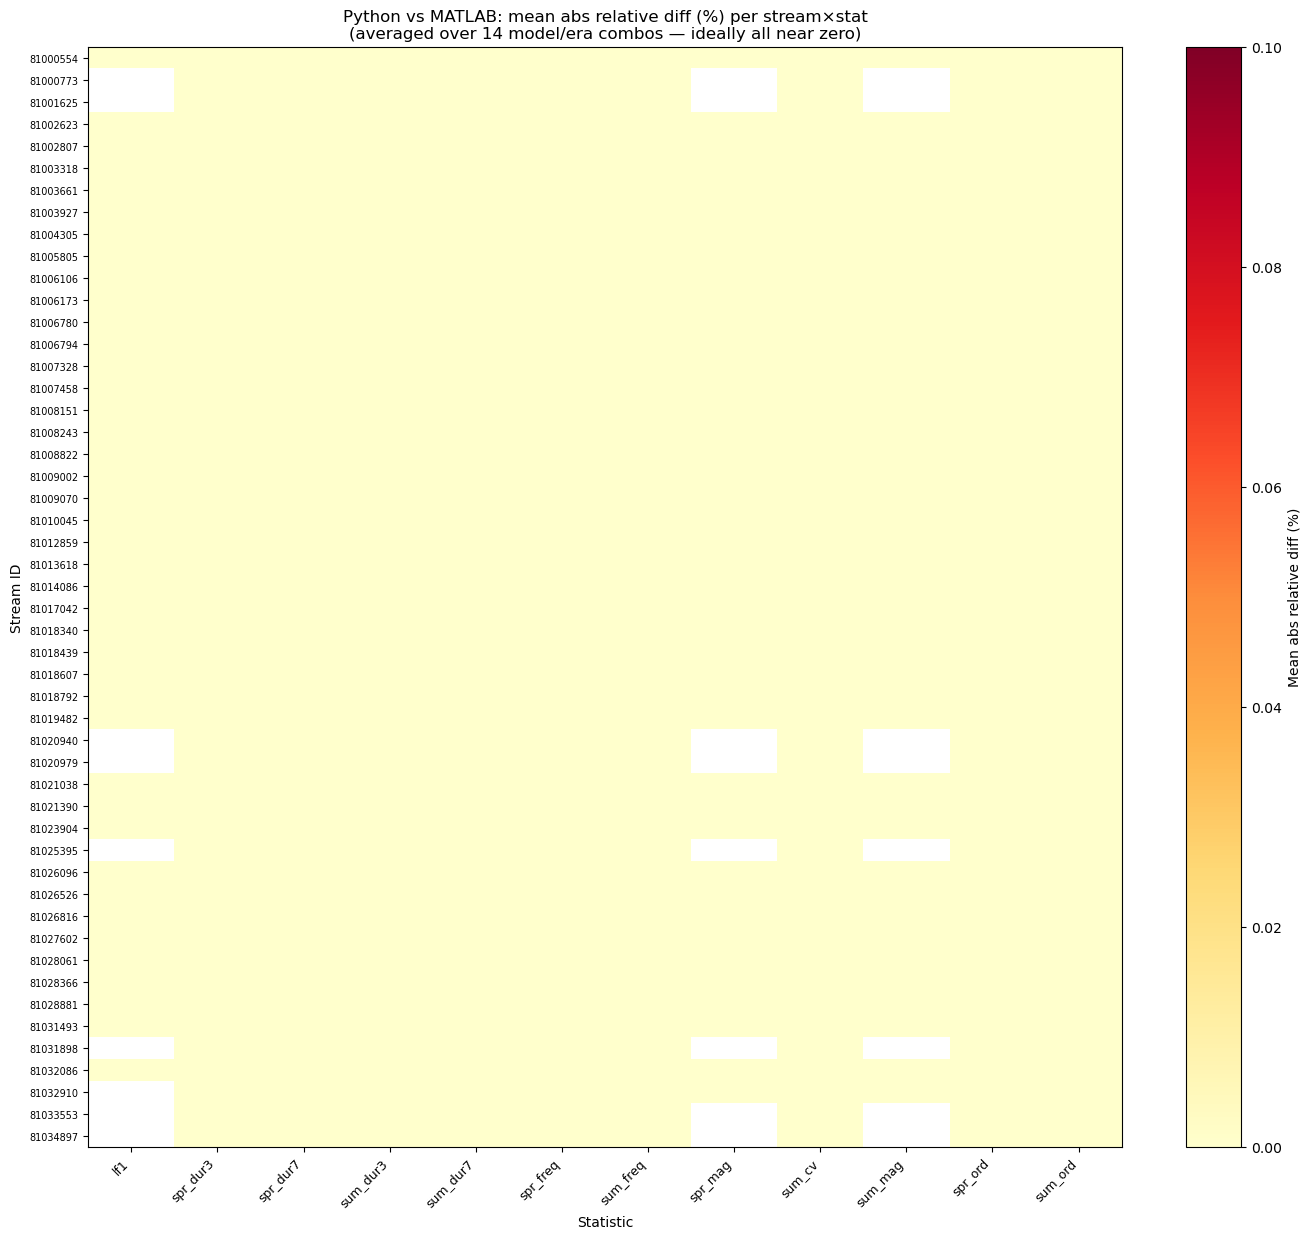

In [11]:
# Build a (stream × stat) matrix of mean relative differences.
heatmap_data = np.full((len(sampled_ids), len(CUSTOM_STATS)), np.nan)

for j, stat in enumerate(CUSTOM_STATS):
    for i, sid in enumerate(sampled_ids):
        rows = results_df[results_df["stream_id"] == sid]
        py = rows[f"{stat}_py"].values
        ml = rows[f"{stat}_ml"].values
        both_finite = np.isfinite(py) & np.isfinite(ml)
        nonzero_ml  = both_finite & (np.abs(ml) > 1e-12)
        if nonzero_ml.any():
            rel_diffs = np.abs(py[nonzero_ml] - ml[nonzero_ml]) / np.abs(ml[nonzero_ml]) * 100
            heatmap_data[i, j] = np.mean(rel_diffs)

fig, ax = plt.subplots(figsize=(14, max(8, len(sampled_ids) * 0.25)))
im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="YlOrRd",
    vmin=0, vmax=0.1,
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Mean abs relative diff (%)")
ax.set_xticks(range(len(CUSTOM_STATS)))
ax.set_xticklabels(CUSTOM_STATS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(sampled_ids)))
ax.set_yticklabels(
    [f"{sid}" for sid in sampled_ids],
    fontsize=7
)
ax.set_xlabel("Statistic")
ax.set_ylabel("Stream ID")
ax.set_title(
    "Python vs MATLAB: mean abs relative diff (%) per stream×stat\n"
    "(averaged over 14 model/era combos — ideally all near zero)"
)
plt.tight_layout()
plt.show()

### 7c. Python vs MATLAB scatter plots

One scatter plot per statistic. Each point is one (stream, model, era) combination.
A perfect implementation lands exactly on the 1:1 diagonal. Points are colored by model
to make it easy to spot model-specific anomalies.

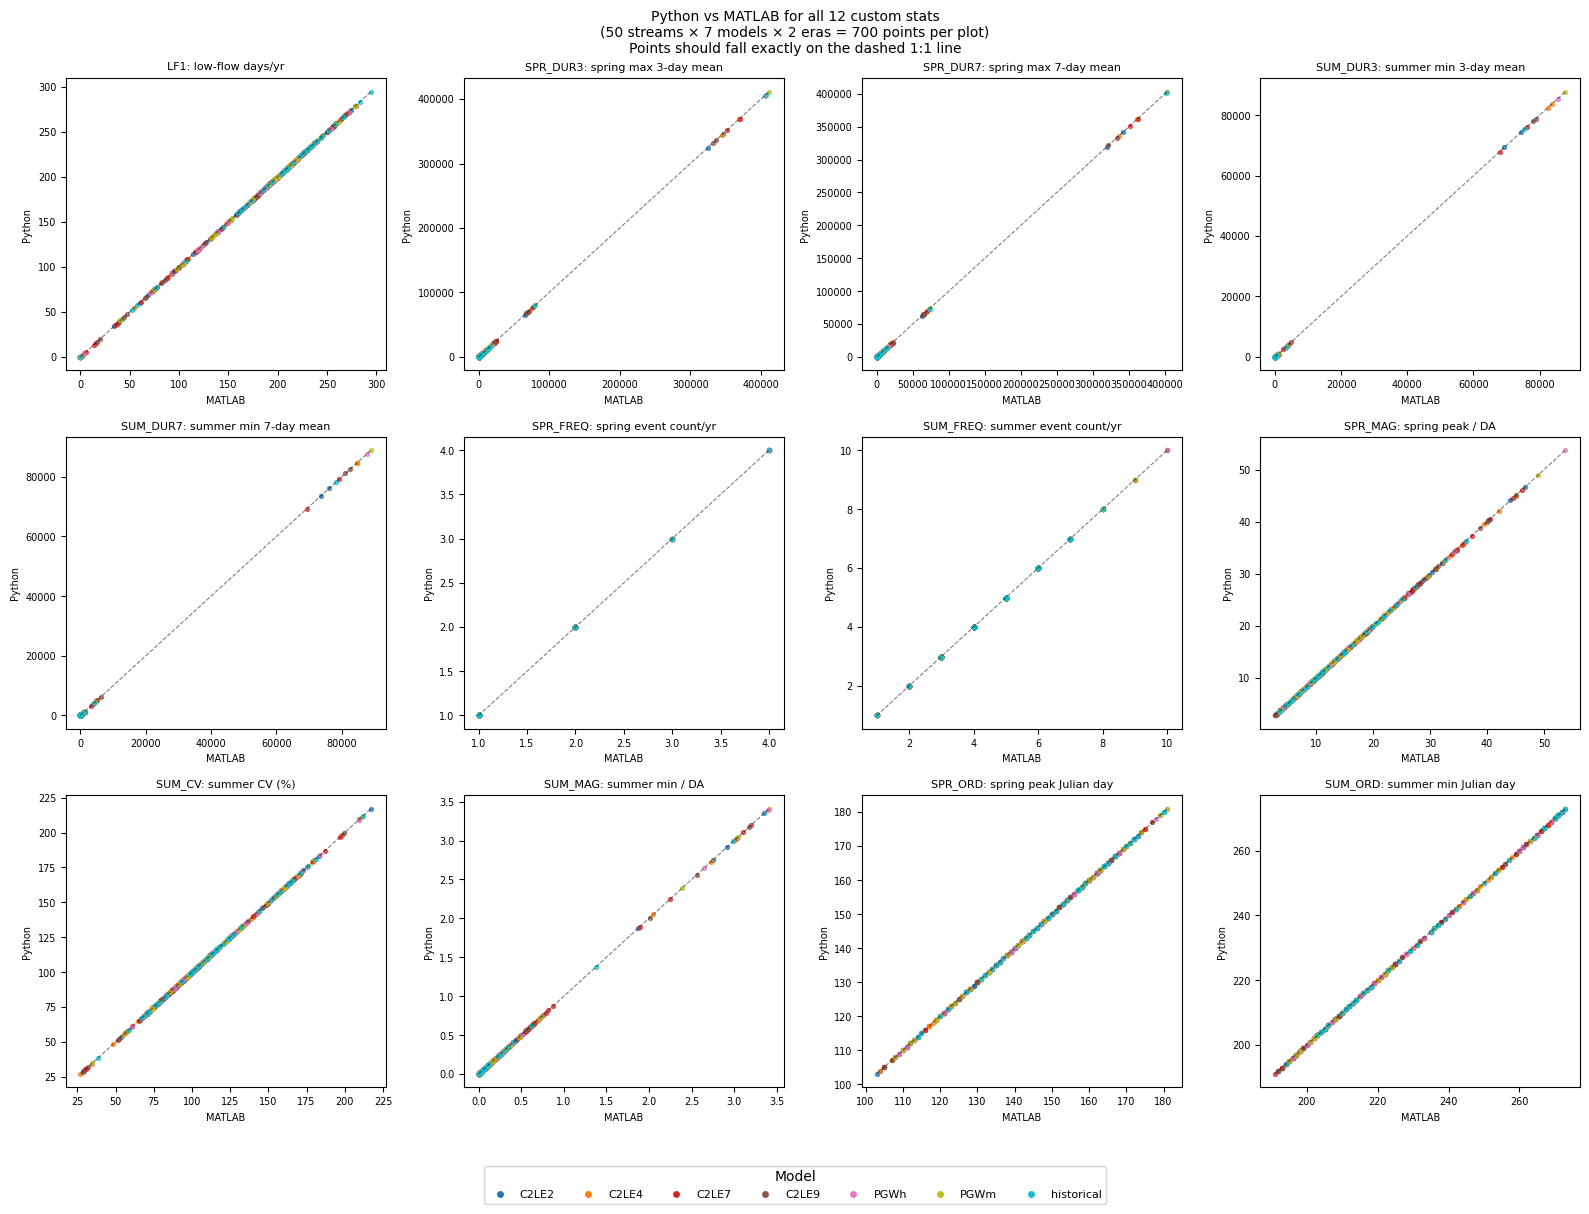

Saved qc_matlab_scatter.png


In [12]:
model_colors = plt.cm.tab10(np.linspace(0, 1, len(MODELS)))
color_map    = dict(zip(MODELS, model_colors))

ncols = 4
nrows = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12))
axes = axes.flatten()

for ax, stat in zip(axes, CUSTOM_STATS):
    for model in MODELS:
        sub = results_df[results_df["model"] == model]
        py_vals = sub[f"{stat}_py"].values
        ml_vals = sub[f"{stat}_ml"].values
        both_ok = np.isfinite(py_vals) & np.isfinite(ml_vals)
        if both_ok.any():
            ax.scatter(
                ml_vals[both_ok], py_vals[both_ok],
                s=8, alpha=0.7,
                color=color_map[model], label=model,
            )

    # 1:1 line
    all_py = results_df[f"{stat}_py"].values
    all_ml = results_df[f"{stat}_ml"].values
    both_ok = np.isfinite(all_py) & np.isfinite(all_ml)
    if both_ok.any():
        lo = min(all_ml[both_ok].min(), all_py[both_ok].min())
        hi = max(all_ml[both_ok].max(), all_py[both_ok].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)

    ax.set_title(STAT_LABELS[stat], fontsize=8)
    ax.set_xlabel("MATLAB", fontsize=7)
    ax.set_ylabel("Python", fontsize=7)
    ax.tick_params(labelsize=7)

# Shared legend
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color_map[m],
               markersize=6, label=m)
    for m in MODELS
]
fig.legend(
    handles=handles, title="Model",
    loc="lower center", ncol=len(MODELS),
    bbox_to_anchor=(0.5, -0.02), fontsize=8
)
fig.suptitle(
    "Python vs MATLAB for all 12 custom stats\n"
    "(50 streams × 7 models × 2 eras = 700 points per plot)\n"
    "Points should fall exactly on the dashed 1:1 line",
    fontsize=10
)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("qc_matlab_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved qc_matlab_scatter.png")

### 7d. Distribution of relative differences

Histogram of all relative differences across every stat and comparison.
The expected distribution is a tight spike near zero; a long tail would indicate
a systematic disagreement.

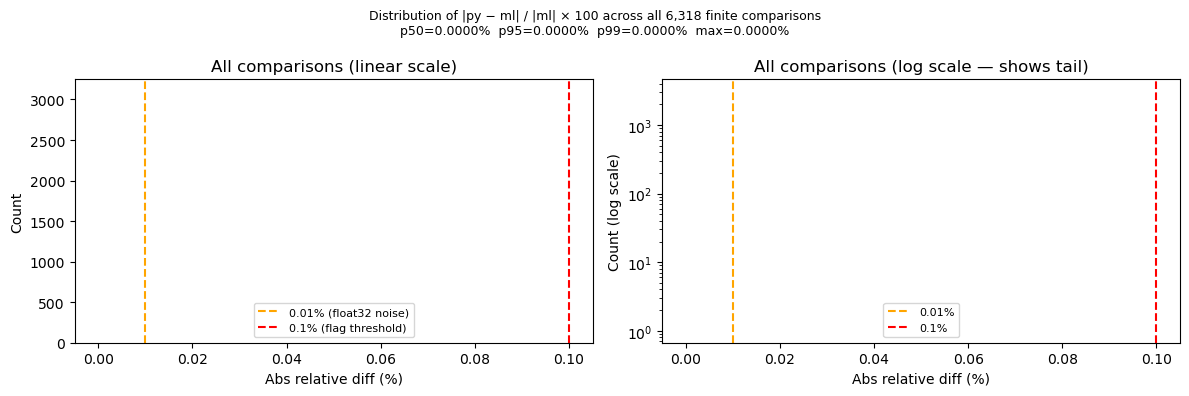

Saved qc_matlab_reldiff_hist.png


In [13]:
all_rel_diffs = []
for stat in CUSTOM_STATS:
    py = results_df[f"{stat}_py"].values
    ml = results_df[f"{stat}_ml"].values
    both_finite = np.isfinite(py) & np.isfinite(ml)
    nonzero_ml  = both_finite & (np.abs(ml) > 1e-12)
    if nonzero_ml.any():
        rd = np.abs(py[nonzero_ml] - ml[nonzero_ml]) / np.abs(ml[nonzero_ml]) * 100
        all_rel_diffs.extend(rd.tolist())

all_rel_diffs = np.array(all_rel_diffs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_rel_diffs, bins=100, color="steelblue", edgecolor="none")
axes[0].axvline(0.01, color="orange", linestyle="--", label="0.01% (float32 noise)")
axes[0].axvline(0.1,  color="red",    linestyle="--", label="0.1% (flag threshold)")
axes[0].set_xlabel("Abs relative diff (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("All comparisons (linear scale)")
axes[0].legend(fontsize=8)

axes[1].hist(all_rel_diffs, bins=100, color="steelblue", edgecolor="none")
axes[1].set_yscale("log")
axes[1].axvline(0.01, color="orange", linestyle="--", label="0.01%")
axes[1].axvline(0.1,  color="red",    linestyle="--", label="0.1%")
axes[1].set_xlabel("Abs relative diff (%)")
axes[1].set_ylabel("Count (log scale)")
axes[1].set_title("All comparisons (log scale — shows tail)")
axes[1].legend(fontsize=8)

plt.suptitle(
    f"Distribution of |py − ml| / |ml| × 100 across all {len(all_rel_diffs):,} finite comparisons\n"
    f"p50={np.percentile(all_rel_diffs,50):.4f}%  "
    f"p95={np.percentile(all_rel_diffs,95):.4f}%  "
    f"p99={np.percentile(all_rel_diffs,99):.4f}%  "
    f"max={np.max(all_rel_diffs):.4f}%",
    fontsize=9
)
plt.tight_layout()
plt.savefig("qc_matlab_reldiff_hist.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved qc_matlab_reldiff_hist.png")

## 8. Conclusion

Interpret the results here after running the notebook. Key things to check:

1. **Summary table** (section 7a): all `max_rel_diff_%` should be green (< 0.01%) or at most
   yellow (0.01–0.1%). Yellow is acceptable and explained by float32 storage in the NetCDF.
   Red (> 0.1%) would indicate a potential bug.

2. **NaN mismatches** (section 7a): should be zero. Any row where Python returns NaN
   but MATLAB returned a number (or vice versa) indicates a logic difference worth
   investigating.

3. **Scatter plots** (section 7c): all 12 plots should show points tightly on the
   1:1 line with no visible deviation or outliers.

4. **Histogram** (section 7d): the distribution should be a spike at or very near 0%
   with no long tail beyond 0.1%.

If all four checks pass, the MATLAB `custom_stats.m` output can be considered validated.